<a href="https://colab.research.google.com/github/jarx108/EV-Analysis/blob/dev/Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 6330 Data Science


In [ ]:
# Imports required for the notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Wrangling/Data Exploration

In [ ]:
# Step 1: Load the data
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

###### 1. Exploratory Data Analysis (EDA) & Cleaning ######

In [ ]:
# Check structure by printing a concise summary of the DataFrame:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280833 entries, 0 to 280832
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         280833 non-null  object 
 1   County                                             280821 non-null  object 
 2   City                                               280821 non-null  object 
 3   State                                              280833 non-null  object 
 4   Postal Code                                        280821 non-null  float64
 5   Model Year                                         280833 non-null  int64  
 6   Make                                               280833 non-null  object 
 7   Model                                              280833 non-null  object 
 8   Electric Vehicle Type                              280833 non-null  object

In [ ]:
# Check Missing Values:
# Number of rows in the dataset
total_rows = len(df)
print(f"\nTotal number of rows in the dataset: {total_rows}\n")


Total number of rows in the dataset: 280833



In [ ]:
# Number of missing values:
missing_values = df.isna().sum()
print(f"Total count of missing values per column: \n{missing_values}\n")

Total count of missing values per column: 
VIN (1-10)                                             0
County                                                12
City                                                  12
State                                                  0
Postal Code                                           12
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        12
Legislative District                                 703
DOL Vehicle ID                                         0
Vehicle Location                                      20
Electric Utility                                      12
2020 Census Tract                                     12
dtype: int64



###### 2. Data Cleaning & Column Standardization ######

In [ ]:
# Remove rows with missing critical data
df_cleaned = df.dropna(subset=['County', 'Vehicle Location', 'Model Year', 'Electric Vehicle Type'])
len_after_dropping = len(df_cleaned)
print(f"Number of rows dropped due to missing values in critical columns: {total_rows - len_after_dropping}\n")
print(f"Number of rows after dropping rows with missing values in critical columns: {len(df_cleaned)}\n")

Number of rows dropped due to missing values in critical columns: 20

Number of rows after dropping rows with missing values in critical columns: 280813



In [ ]:
# Extract Latitude and Longitude from the 'Vehicle Location' string
def parse_coords(loc):
    try:
       # Format: POINT (-122.22901 47.72201)
       coords = loc.replace('POINT (', '').replace(')', '').split()
       return float(coords[0]), float(coords[1])
    except (IndexError, ValueError, AttributeError):
        return None, None


In [ ]:
# Apply parsing to create new columns
df_cleaned[['Longitude', 'Latitude']] = df_cleaned['Vehicle Location'].apply(lambda x: pd.Series(parse_coords(x)))

/tmp/ipykernel_8588/102585341.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[['Longitude', 'Latitude']] = df_cleaned['Vehicle Location'].apply(lambda x: pd.Series(parse_coords(x)))
/tmp/ipykernel_8588/102585341.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[['Longitude', 'Latitude']] = df_cleaned['Vehicle Location'].apply(lambda x: pd.Series(parse_coords(x)))


In [ ]:
# Standardize column names for consistency
df_cleaned.columns = [c.replace(' ', '_').lower() for c in df_cleaned.columns]

In [ ]:
# Save the cleaned dataset to csv file
# filename = 'cleaned_ev_data.csv'
# df_cleaned.to_csv(filename, index=False)
# print(f"Cleaned dataset saved to {filename}")

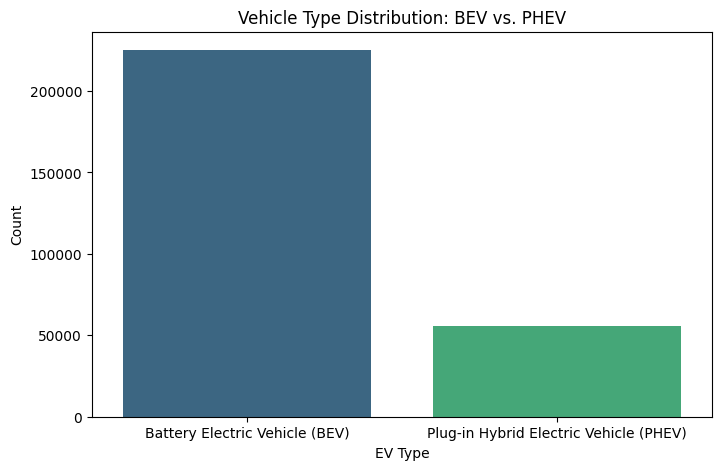

In [ ]:
# Step 3: Exploratory Data Analysis (EDA)
# Vehicle Type Distribution
# Helps determine the ratio of BEV vs PHEV chargers needed.
plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='electric_vehicle_type', hue='electric_vehicle_type', palette='viridis', legend=False)
plt.title('Vehicle Type Distribution: BEV vs. PHEV')
plt.xlabel('EV Type')
plt.ylabel('Count')
plt.show()

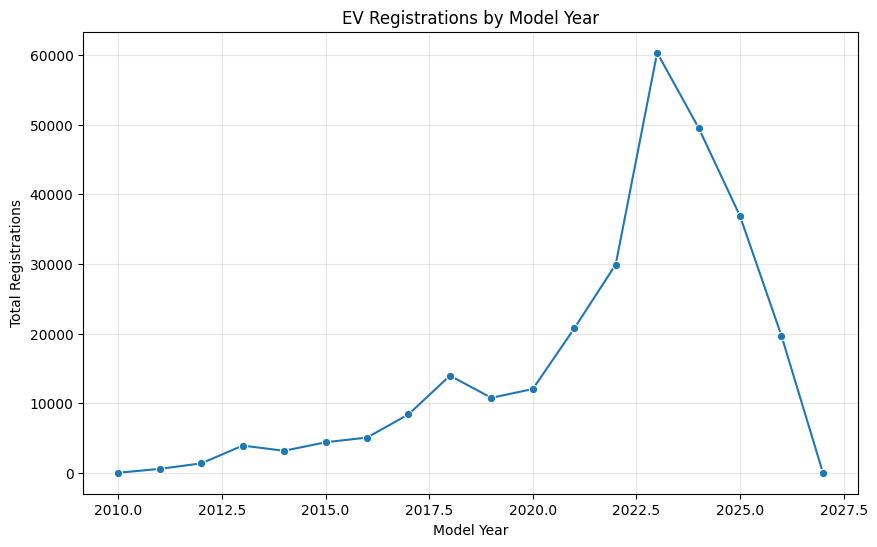

In [ ]:
# Historical Growth Trend
# Validates the exponential growth for future time-series forecasting.
growth = df_cleaned[df_cleaned['model_year'] >=2010].groupby('model_year').size().reset_index(name='count')
plt.figure(figsize=(10,6))
sns.lineplot(data=growth, x='model_year', y='count', marker='o')
plt.title('EV Registrations by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Total Registrations')
plt.grid(True, alpha=0.3)
plt.show()

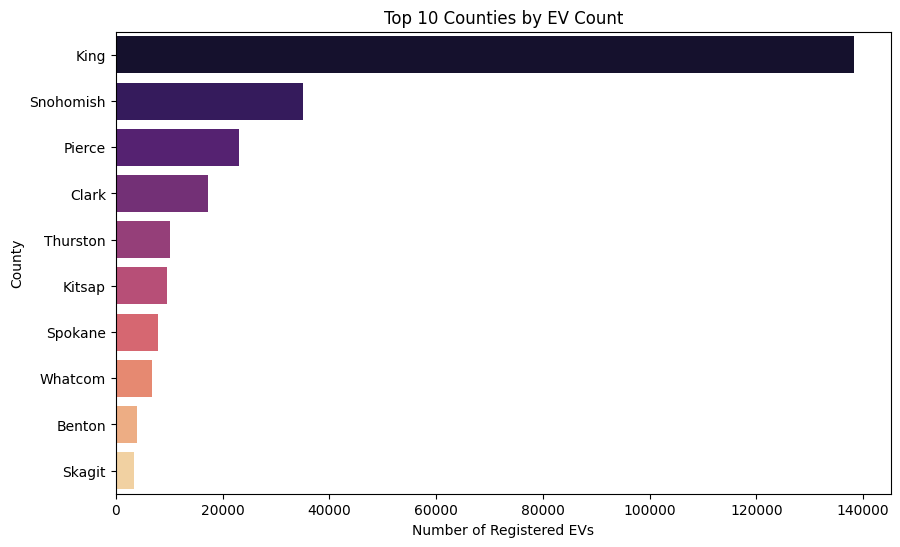

In [ ]:
# Top Counties by Density
# Identifies which regions currently have the highest registration density.
top_counties = df_cleaned['county'].value_counts().head(10).reset_index()
top_counties.columns = ['county', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_counties, x='count', y='county', hue='county', palette='magma', legend=False)
plt.title('Top 10 Counties by EV Count')
plt.xlabel('Number of Registered EVs')
plt.ylabel('County')
plt.show()

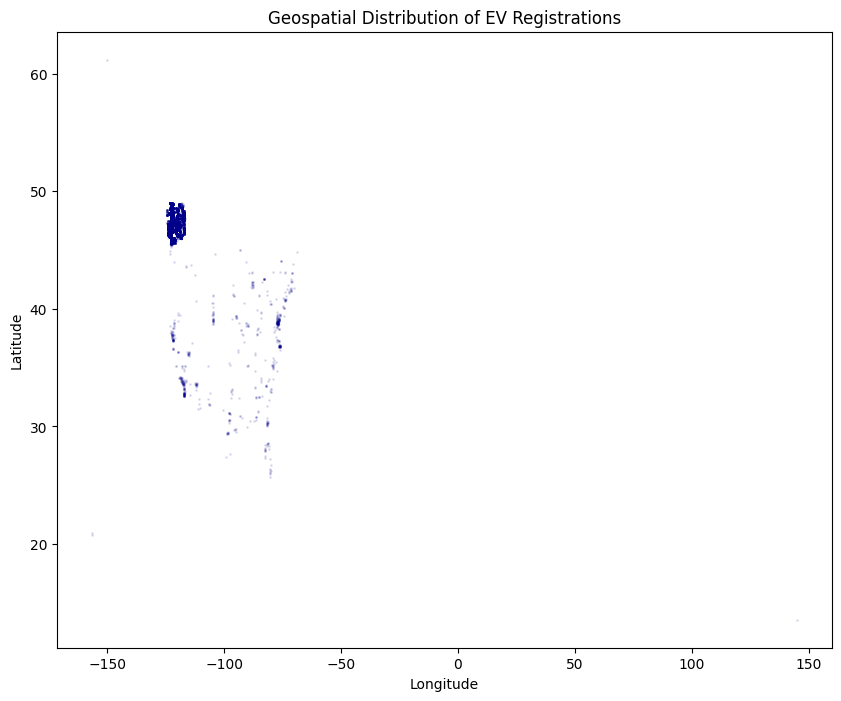

In [ ]:
# Geospatial Distribution (Hotspot Check)
# A scatter plot of Latitude and Longitude to visualize geographic clusters.
plt.figure(figsize=(10, 8))
plt.scatter(df_cleaned['longitude'], df_cleaned['latitude'], alpha=0.1, s=1, c='DarkBlue')
plt.title('Geospatial Distribution of EV Registrations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# 2. Regression

In [ ]:
test

# 3. Evaluate Model Performance

In [ ]:
test

# 4. Supervised/Unsupervised Learning

In [ ]:
test